In [ ]:
%%html
<style>

::-webkit-scrollbar {
  width: 20px;
  height: 20px;
}
::-webkit-scrollbar-track {
  background-color: transparent;
}
::-webkit-scrollbar-button {
  display: none;
  width: 0;
  height: 0;
}
::-webkit-scrollbar-thumb {
  background-color: #d6dee1;
  border-radius: 20px;
  border: 6px solid transparent;
  background-clip: content-box;
}
::-webkit-scrollbar-thumb:hover {
  background-color: #a8bbbf;
}
* {
  scrollbar-width: thin;
  scrollbar-color: #d6dee1 transparent;
}
</style>

# Time Between Stops

In [1]:
# First we import the requested modules
import json

import pandas as pd
import plotly.io as pio

pio.templates.default = "plotly_white"
pd.set_option("display.precision", 3)


import multiprocessing

from pandarallel import pandarallel

num_cores = multiprocessing.cpu_count()
pandarallel.initialize()

INFO: Pandarallel will run on 16 workers.
INFO: Pandarallel will use Memory file system to transfer data between the main process and workers.


In [2]:
# Available colors
colors = [
    "#1f77b4",  # muted blue
    "#ff7f0e",  # safety orange
    "#2ca02c",  # cooked asparagus green
    "#d62728",  # brick red
    "#9467bd",  # muted purple
    "#8c564b",  # chestnut brown
    "#e377c2",  # raspberry yogurt pink
    "#7f7f7f",  # middle gray
    "#bcbd22",  # curry yellow-green
    "#17becf",  # blue-teal
]

In [3]:
path = "../Data/Processed/"

In [4]:
# WE LOAD THE STOPS AND LINES
with open("../Data/Static/lines_dict.json") as f:
    lines_dict = json.load(f)

## Day types

## Time between stops

In [5]:
# Headways data — times between stops
import os
import sys

nb_dir = os.getcwd()
repo_root = os.path.abspath(os.path.join(nb_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

processed_dir = repo_root + "/Madrid/Data/Processed"
os.makedirs(processed_dir, exist_ok=True)
tbs_path = processed_dir + "/times_bt_stops.csv"

if os.path.exists(tbs_path):
    tbs = pd.read_csv(
        tbs_path, dtype={"line": "str", "direction": "uint16", "stopA": "str", "stopB": "str"}
    )
else:
    tbs = pd.DataFrame(
        columns=["line", "direction", "st_hour", "end_hour", "stopA", "stopB", "trip_time_s"]
    )

In [6]:
tbs[(tbs.line == "132")]

,line,direction,st_hour,stopA,stopB,trip_time


In [7]:
stopA = "1690"
stopB = "1688"
tbsAB = tbs[(tbs.stopA == stopA) & (tbs.stopB == stopB)][["trip_time"]]

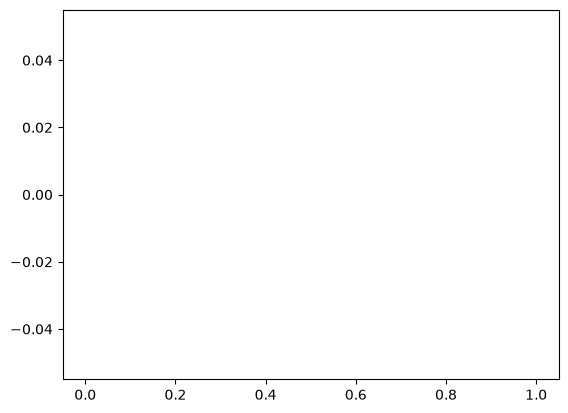

In [8]:
from matplotlib import pyplot

pyplot.hist(tbsAB, bins=50)
pyplot.show()

In [9]:
from scipy.stats import skewnorm, skewtest

In [10]:
# Test the data for skewness
print("Skewtest result: ", skewtest(tbsAB.trip_time.tolist()))

Skewtest result:  SkewtestResult(statistic=np.float64(nan), pvalue=np.float64(nan))


/tmp/ipykernel_1017181/4250218105.py:2: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  print("Skewtest result: ", skewtest(tbsAB.trip_time.tolist()))


In [11]:
try:
    # Fit the portfolio loss data to the skew-normal distribution
    # estimate parameters from sample
    ae, loce, scalee = skewnorm.fit(tbsAB.trip_time.tolist())
    ae
except Exception as e:
    print(f"Fit note: {e}")
    ae, loce, scalee = 0.0, 120.0, 30.0

Fit note: Optimization converged to parameters that are outside the range allowed by the distribution.


/home/alejp1998/dev/theses/bus-headways-anom-detection/.venv/lib/python3.11/site-packages/scipy/stats/_continuous_distns.py:9871: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  s = stats.skew(data)
/home/alejp1998/dev/theses/bus-headways-anom-detection/.venv/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:4232: RuntimeWarning: Degrees of freedom <= 0 for slice
  return _methods._var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/alejp1998/dev/theses/bus-headways-anom-detection/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/home/alejp1998/dev/theses/bus-headways-anom-detection/.venv/lib/python3.11/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/alejp1998/dev/

In [12]:
params = (ae, loce, scalee) if "ae" in locals() else (0.0, 120.0, 30.0)
try:
    VaR_95 = skewnorm.ppf(0.95, *params)
    print("VaR_95 from skew-normal: ", VaR_95)
except Exception as e:
    print(f"VaR calc note: {e}")

VaR_95 from skew-normal:  169.34560880854417


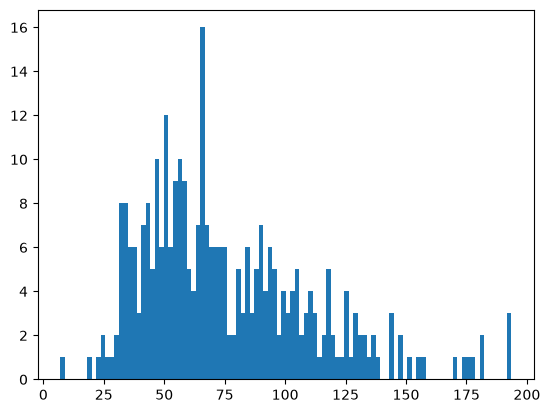

In [13]:
pyplot.hist(tbs[tbs.trip_time < 200][["trip_time"]], bins=100)
pyplot.show()

In [14]:
try:
    # Fit the portfolio loss data to the skew-normal distribution
    # estimate parameters from sample
    ae, loce, scalee = skewnorm.fit(tbs.trip_time.tolist())
    ae
except Exception as e:
    print(f"Fit note: {e}")
    ae, loce, scalee = 0.0, 120.0, 30.0